# Lesson 4: Statistical Distributions

## Bernoulli, Binomial, Poisson, Normal, and Standardization

In this notebook we will:
- Compute PMFs, PDFs, and CDFs using scipy.stats
- Visualize all four distributions
- Standardize data to Z-scores
- Apply distributions to real-world problems

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.style.use('ggplot')
%matplotlib inline

## 1. Bernoulli Distribution

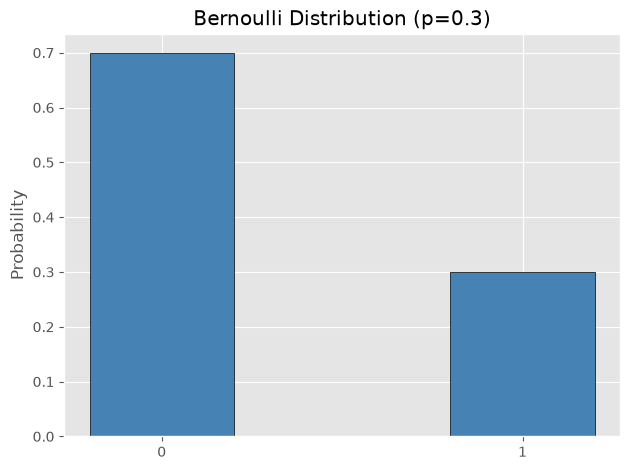

Mean: 0.30, Variance: 0.21


In [2]:
p = 0.3
bernoulli = stats.bernoulli(p)
x = [0, 1]
plt.bar(x, bernoulli.pmf(x), width=0.4, color='steelblue', edgecolor='black')
plt.xticks([0, 1])
plt.title(f'Bernoulli Distribution (p={p})')
plt.ylabel('Probability')
plt.tight_layout()
plt.show()
print(f"Mean: {bernoulli.mean():.2f}, Variance: {bernoulli.var():.2f}")

## 2. Binomial Distribution

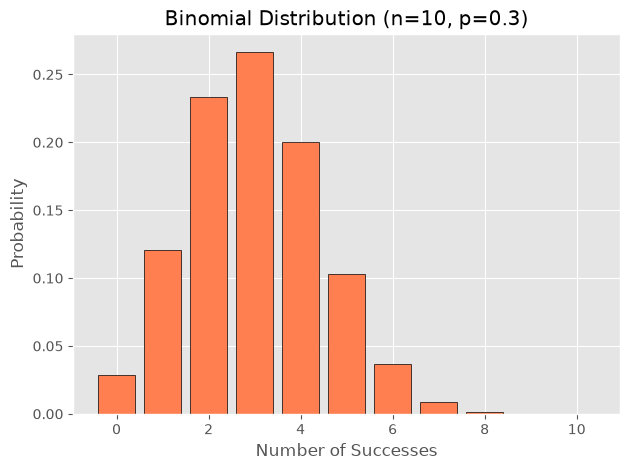

P(X=3) = 0.267
P(X >= 5) = 0.150
Mean: 3.00, Variance: 2.10


In [3]:
n, p = 10, 0.3
binom = stats.binom(n, p)
k = np.arange(0, n+1)
plt.bar(k, binom.pmf(k), width=0.8, color='coral', edgecolor='black')
plt.title(f'Binomial Distribution (n={n}, p={p})')
plt.xlabel('Number of Successes')
plt.ylabel('Probability')
plt.tight_layout()
plt.show()
print(f"P(X=3) = {binom.pmf(3):.3f}")
print(f"P(X >= 5) = {1 - binom.cdf(4):.3f}")
print(f"Mean: {binom.mean():.2f}, Variance: {binom.var():.2f}")

## 3. Poisson Distribution

<>:5: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:5: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/tmp/ipykernel_34589/2767070308.py:5: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  plt.title(f'Poisson Distribution ($\lambda$={lam})')


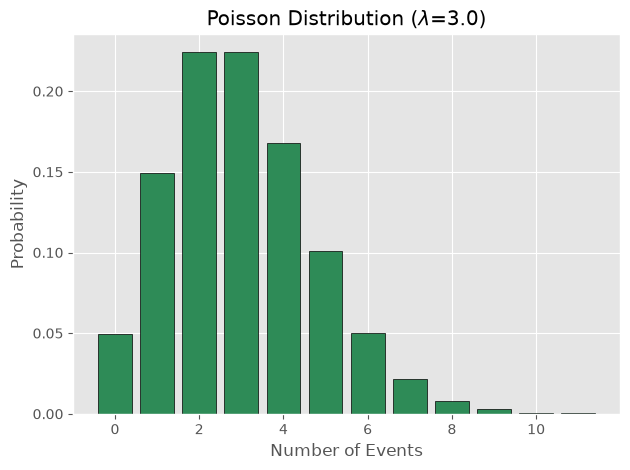

P(X=2) = 0.224
Mean: 3.00, Variance: 3.00


In [4]:
lam = 3.0
poisson = stats.poisson(lam)
k = np.arange(0, 12)
plt.bar(k, poisson.pmf(k), width=0.8, color='seagreen', edgecolor='black')
plt.title(f'Poisson Distribution ($\lambda$={lam})')
plt.xlabel('Number of Events')
plt.ylabel('Probability')
plt.tight_layout()
plt.show()
print(f"P(X=2) = {poisson.pmf(2):.3f}")
print(f"Mean: {poisson.mean():.2f}, Variance: {poisson.var():.2f}")

## 4. Normal Distribution

<>:6: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:6: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:6: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:6: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/tmp/ipykernel_34589/3290276550.py:6: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.title(f'Normal Distribution ($\mu$={mu}, $\sigma$={sigma})')
/tmp/ipykernel_34589/3290276550.py:6: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did

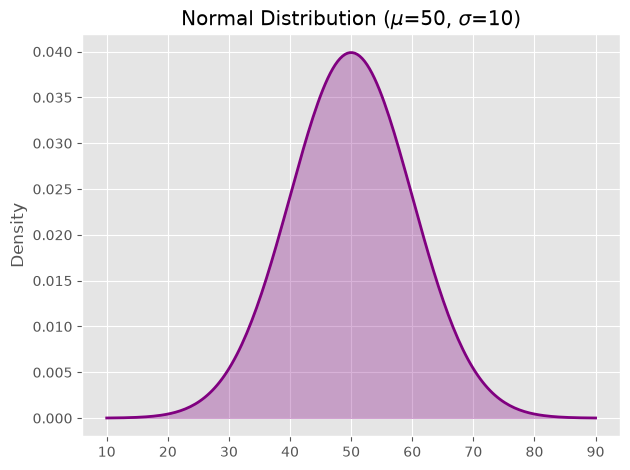

P(X < 60) = 0.841
P(40 < X < 60) = 0.683
95% interval: [30.4, 69.6]


In [5]:
mu, sigma = 50, 10
normal = stats.norm(mu, sigma)
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
plt.plot(x, normal.pdf(x), color='purple', linewidth=2)
plt.fill_between(x, normal.pdf(x), alpha=0.3, color='purple')
plt.title(f'Normal Distribution ($\mu$={mu}, $\sigma$={sigma})')
plt.ylabel('Density')
plt.tight_layout()
plt.show()
print(f"P(X < 60) = {normal.cdf(60):.3f}")
print(f"P(40 < X < 60) = {normal.cdf(60) - normal.cdf(40):.3f}")
print(f"95% interval: [{normal.ppf(0.025):.1f}, {normal.ppf(0.975):.1f}]")

## 5. Standardization (Z-scores)

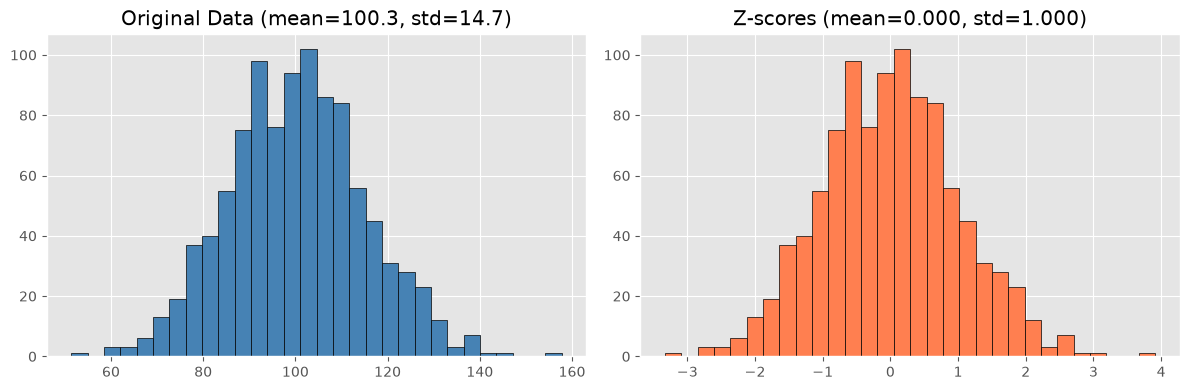

In [6]:
np.random.seed(42)
data = np.random.normal(loc=100, scale=15, size=1000)
z_scores = (data - np.mean(data)) / np.std(data, ddof=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(data, bins=30, edgecolor='black', color='steelblue')
axes[0].set_title(f'Original Data (mean={np.mean(data):.1f}, std={np.std(data, ddof=0):.1f})')
axes[1].hist(z_scores, bins=30, edgecolor='black', color='coral')
axes[1].set_title(f'Z-scores (mean={np.mean(z_scores):.3f}, std={np.std(z_scores, ddof=0):.3f})')
plt.tight_layout()
plt.show()

## 6. 68-95-99.7 Rule

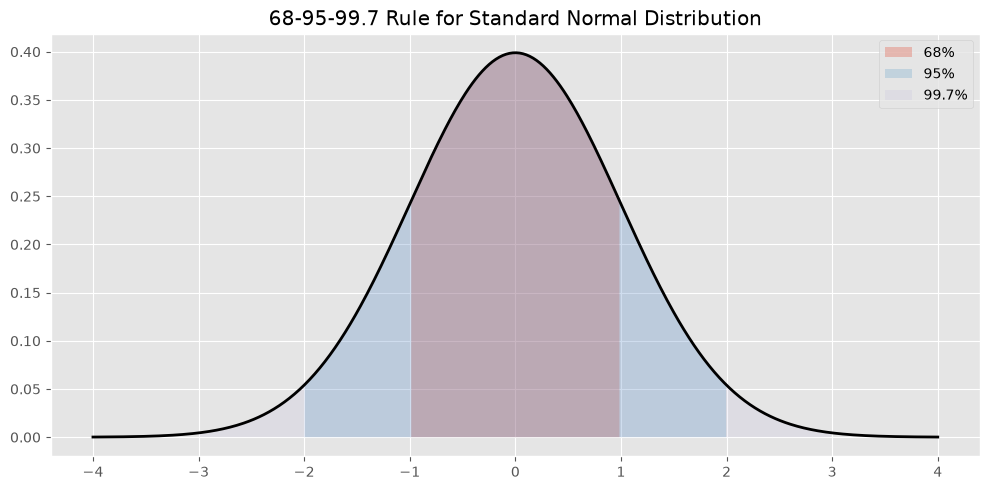

In [7]:
x = np.linspace(-4, 4, 500)
y = stats.norm.pdf(x)

plt.figure(figsize=(10, 5))
plt.plot(x, y, 'black', linewidth=2)
plt.fill_between(x, y, where=(x >= -1) & (x <= 1), alpha=0.3, label='68%')
plt.fill_between(x, y, where=(x >= -2) & (x <= 2), alpha=0.2, label='95%')
plt.fill_between(x, y, where=(x >= -3) & (x <= 3), alpha=0.1, label='99.7%')
plt.title('68-95-99.7 Rule for Standard Normal Distribution')
plt.legend()
plt.tight_layout()
plt.show()

## Exercises

1. For Binomial(n=20, p=0.7), compute P(X >= 15).
2. Generate 1000 samples from N(100, 20), standardize, verify mean ≈ 0, std ≈ 1.
3. Create a 2x2 subplot with PMF/PDF of all 4 distributions covered in this lesson.